In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib.ticker import PercentFormatter
import matplotlib.pyplot as plt


PROJECT_ROOT = Path("/Users/ydnkka/Desktop/PhD Project/projects/scotland")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils import window_policy_lookup  # noqa: E402
from utils import new_figure  # noqa: E402

In [18]:
ass = pd.read_parquet(
    PROJECT_ROOT
    / "chapter_analyses/genomic_networks/results/tables/compatibility_assortativity_bootstrap.parquet"
)

In [19]:
windows = window_policy_lookup(ass["window_id"].unique())
ass = ass.merge(windows, on="window_id", how="left")
ass = ass.dropna(subset=["assortativity"])

In [20]:
ass.columns

Index(['attribute', 'attribute_label', 'window_id', 'pango_lineage',
       'n_edges_observed', 'n_edges_used', 'edge_weight_total', 'n_categories',
       'assortativity', 'observed_same_category_weight',
       'expected_same_category_weight', 'uncertainty_method',
       'bootstrap_replicates', 'bootstrap_finite_replicates',
       'assortativity_se', 'assortativity_ci_low', 'assortativity_ci_high',
       'skipped_reason', 'pairwise_stem', 'window_idx', 'wn_mid_date',
       'stringency_index', 'containment_index', 'policy_period',
       'policy_period_label', 'policy_period_start_date',
       'policy_period_end_date', 'policy_period_order', 'policy_era'],
      dtype='str')

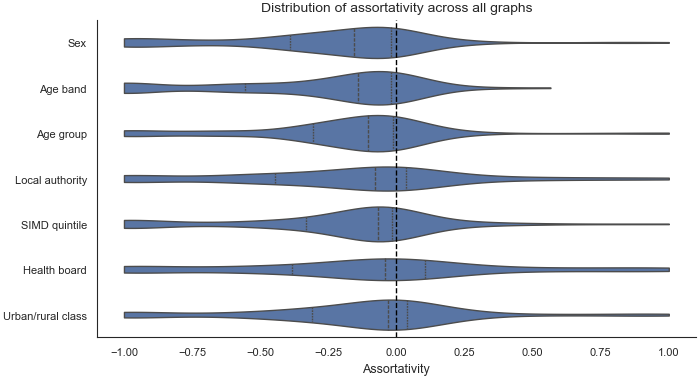

In [28]:
order = (
    ass.groupby("attribute_label", observed=True)["assortativity"]
    .median()
    .sort_values()
    .index
)

_, ax = new_figure(
    width="double",
    height_in=4,
)

sns.violinplot(
    data=ass,
    x="assortativity",
    y="attribute_label",
    order=order,
    inner="quartile",
    cut=0,
    linewidth=1,
    ax=ax,
)

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Assortativity")
plt.ylabel("")
plt.title("Distribution of assortativity across all graphs")
plt.tight_layout()
plt.show()

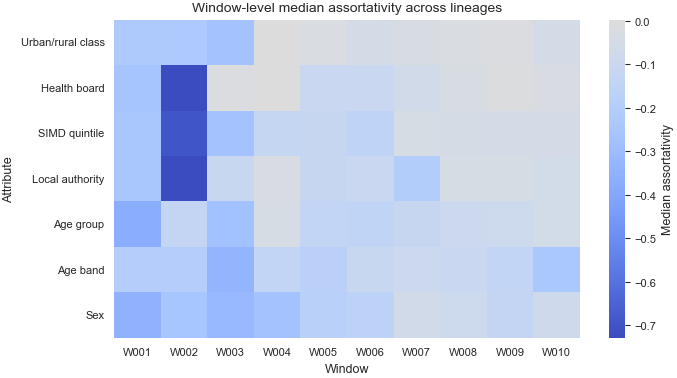

In [31]:
heat = (
    ass.groupby(["attribute_label", "window_id"], observed=True)["assortativity"]
    .median()
    .reset_index()
)

heat_pivot = heat.pivot(
    index="attribute_label", columns="window_id", values="assortativity"
)

attribute_order = (
    ass.groupby("attribute_label", observed=True)["assortativity"]
    .median()
    .sort_values(ascending=False)
    .index
)

heat_pivot = heat_pivot.loc[attribute_order]

_, ax = new_figure(
    width="double",
    height_in=4,
)

sns.heatmap(
    heat_pivot,
    cmap="coolwarm",
    center=0,
    linewidths=0,
    cbar_kws={"label": "Median assortativity"},
    ax=ax,
)

plt.xlabel("Window")
plt.ylabel("Attribute")
plt.title("Window-level median assortativity across lineages")
plt.tight_layout()
plt.show()

In [38]:
def random_effects_pool(
    data,
    est_col="assortativity",
    se_col="assortativity_se",
):
    d = data[[est_col, se_col]].dropna().copy()

    d = d[np.isfinite(d[est_col]) & np.isfinite(d[se_col])]
    d = d[d[se_col] > 0]

    k = len(d)

    if k < 2:
        return pd.Series({
            "n_lineages": k,
            "pooled_mean": np.nan,
            "pooled_se": np.nan,
            "pooled_ci_low": np.nan,
            "pooled_ci_high": np.nan,
            "tau2": np.nan,
            "i2": np.nan,
            "q25": np.nan,
            "q75": np.nan,
            "q05": np.nan,
            "q95": np.nan
        })

    y = d[est_col].to_numpy(dtype=float)
    se = d[se_col].to_numpy(dtype=float)
    v = se ** 2

    # Fixed-effect weights
    w = 1 / v

    mu_fixed = np.sum(w * y) / np.sum(w)

    # Cochran's Q
    q = np.sum(w * (y - mu_fixed) ** 2)

    df_q = k - 1

    c = np.sum(w) - (np.sum(w ** 2) / np.sum(w))

    # DerSimonian-Laird tau^2
    tau2 = max(0, (q - df_q) / c) if c > 0 else 0

    # Random-effects weights
    w_re = 1 / (v + tau2)

    pooled_mean = np.sum(w_re * y) / np.sum(w_re)
    pooled_se = np.sqrt(1 / np.sum(w_re))

    z = 1.96

    pooled_ci_low = pooled_mean - z * pooled_se
    pooled_ci_high = pooled_mean + z * pooled_se

    # Optional: because assortativity is bounded
    pooled_ci_low = max(-1, pooled_ci_low)
    pooled_ci_high = min(1, pooled_ci_high)

    i2 = max(0, (q - df_q) / q) if q > 0 else 0

    return pd.Series({
        "n_lineages": k,
        "pooled_mean": pooled_mean,
        "pooled_se": pooled_se,
        "pooled_ci_low": pooled_ci_low,
        "pooled_ci_high": pooled_ci_high,

        # Between-lineage heterogeneity
        "tau2": tau2,
        "i2": i2,

        # Distribution of point estimates across lineages
        "q25": np.quantile(y, 0.25),
        "q75": np.quantile(y, 0.75),
        "q05": np.quantile(y, 0.05),
        "q95": np.quantile(y, 0.95),
        "median": np.median(y)
    })

window_meta = (
    ass
    .groupby(["attribute", "attribute_label", "window_idx"], observed=True)
    .apply(random_effects_pool)
    .reset_index()
)

In [39]:
def plot_pooled_window_meta(meta, x_col="window_idx", exclude_attrs=None):
    if exclude_attrs is None:
        exclude_attrs = []

    attributes = meta["attribute_label"].dropna().unique()
    attributes = [attr for attr in attributes if attr not in exclude_attrs]

    n_attrs = len(attributes)
    ncols = 3
    nrows = int(np.ceil(n_attrs / ncols))

    fig, axes = new_figure(
        nrows=nrows,
        ncols=ncols,
        width_in=6 * ncols,
        height_in=4.5 * nrows,
        sharex=True,
        sharey=True
    )

    axes = np.array(axes).reshape(-1)

    for ax, attr in zip(axes, attributes):
        d = (
            meta[meta["attribute_label"] == attr]
            .sort_values(x_col)
        )

        x = d[x_col].to_numpy()

        # Bootstrap/SE-informed CI for pooled mean
        ax.fill_between(
            x,
            d["pooled_ci_low"].to_numpy(),
            d["pooled_ci_high"].to_numpy(),
            alpha=0.25,
            color="#4C72B0",
            label="95% CI for pooled mean"
        )

        ax.plot(
            x,
            d["pooled_mean"].to_numpy(),
            color="#4C72B0",
            linewidth=2,
            label="Random-effects pooled mean"
        )

        # Between-lineage IQR
        ax.fill_between(
            x,
            d["q25"].to_numpy(),
            d["q75"].to_numpy(),
            alpha=0.20,
            color="#DD8452",
            label="Between-lineage IQR"
        )

        ax.plot(
            x,
            d["median"].to_numpy(),
            color="#DD8452",
            linewidth=1.5,
            linestyle="--",
            label="Median across lineages"
        )

        ax.axhline(0, color="black", linestyle="--", linewidth=1)

        ax.set_title(str(attr))
        ax.set_xlabel("Window")
        ax.set_ylabel("Assortativity")

    for ax in axes[len(attributes):]:
        ax.remove()

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2)

    fig.tight_layout(rect=(0, 0, 1, 0.94))
    plt.show()

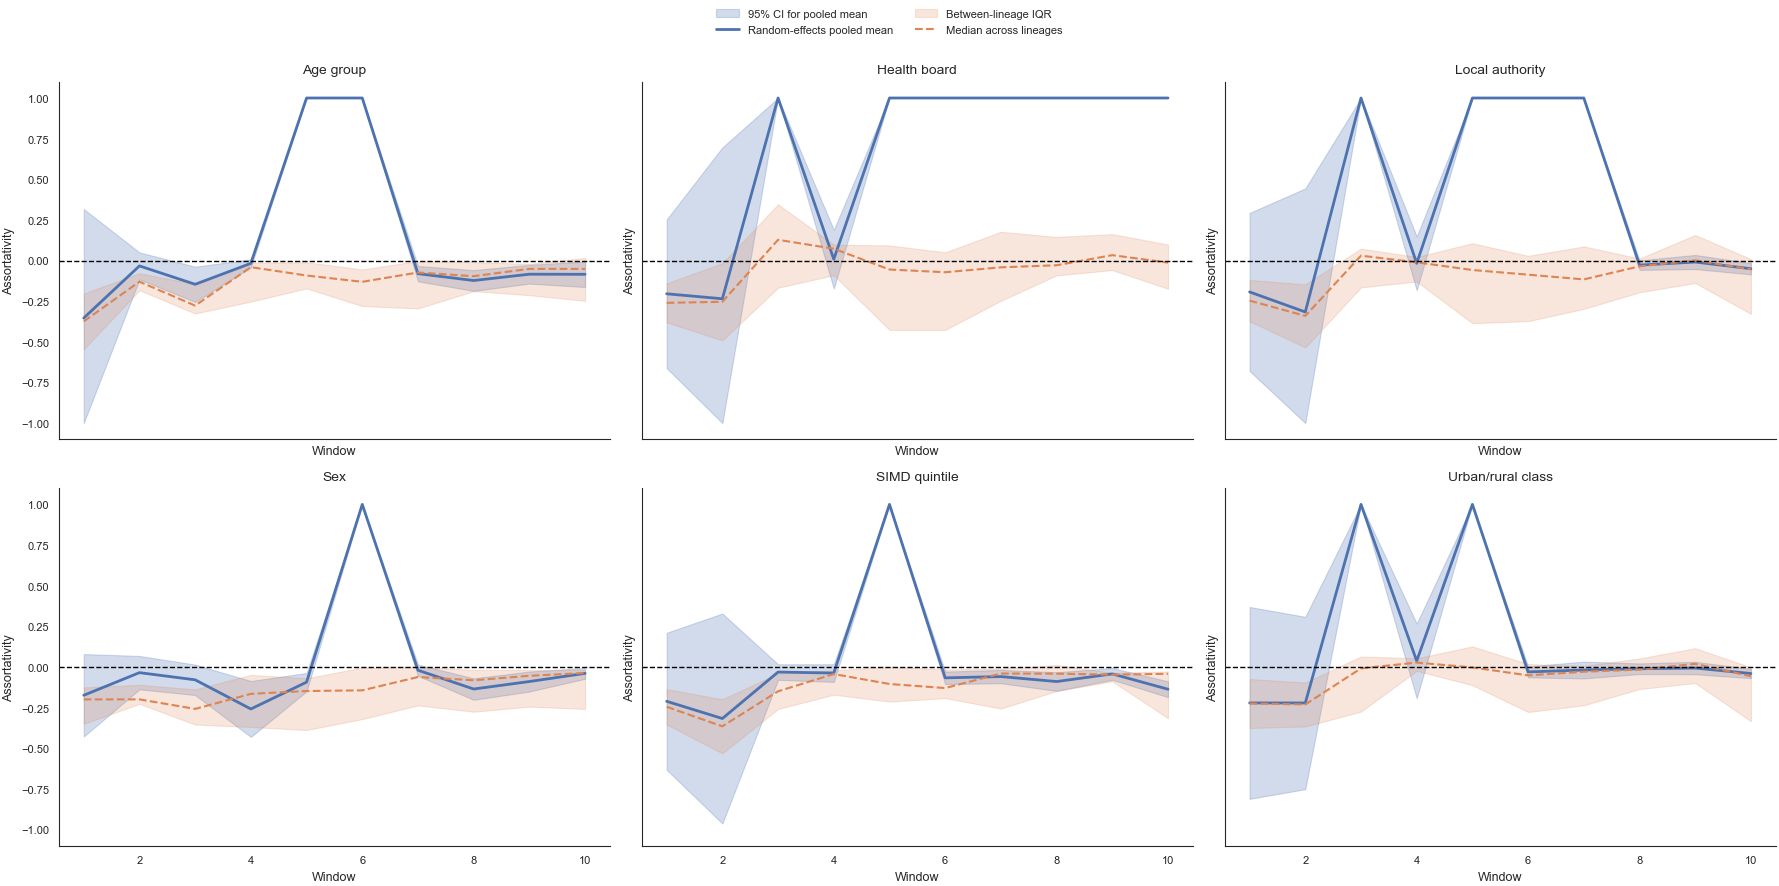

In [40]:
plot_pooled_window_meta(window_meta, exclude_attrs=["Age band"])

In [32]:
import statsmodels.formula.api as smf


def variance_decomposition_additive_model(data):
    d = data[["window_id", "pango_lineage", "assortativity"]].dropna().copy()
    d["assortativity"] = d["assortativity"].astype(float)

    if len(d) < 3:
        return pd.Series(dtype=float)

    # Treat these as categorical factors
    d["window_id"] = d["window_id"].astype("category")
    d["pango_lineage"] = d["pango_lineage"].astype("category")

    y = d["assortativity"]
    ss_total = ((y - y.mean()) ** 2).sum()

    if ss_total <= 0:
        return pd.Series({
            "total_variance": 0.0,
            "window_alone_fraction": np.nan,
            "lineage_alone_fraction": np.nan,
            "additive_model_fraction": np.nan,
            "lineage_given_window_fraction": np.nan,
            "window_given_lineage_fraction": np.nan,
            "residual_fraction_additive": np.nan,
        })

    # Null model
    m0 = smf.ols("assortativity ~ 1", data=d).fit()

    # One-factor models
    m_window = smf.ols("assortativity ~ C(window_id)", data=d).fit()
    m_lineage = smf.ols("assortativity ~ C(pango_lineage)", data=d).fit()

    # Additive two-factor model
    m_both = smf.ols(
        "assortativity ~ C(window_id) + C(pango_lineage)",
        data=d
    ).fit()

    ss_window_alone = m0.ssr - m_window.ssr
    ss_lineage_alone = m0.ssr - m_lineage.ssr

    ss_additive = m0.ssr - m_both.ssr

    ss_lineage_given_window = m_window.ssr - m_both.ssr
    ss_window_given_lineage = m_lineage.ssr - m_both.ssr

    ss_residual = m_both.ssr

    return pd.Series({
        "n": len(d),
        "n_windows": d["window_id"].nunique(),
        "n_lineages": d["pango_lineage"].nunique(),

        "total_variance": ss_total / (len(d) - 1),

        "window_alone_fraction": ss_window_alone / ss_total,
        "lineage_alone_fraction": ss_lineage_alone / ss_total,

        "additive_model_fraction": ss_additive / ss_total,
        "residual_fraction_additive": ss_residual / ss_total,

        "lineage_given_window_fraction": ss_lineage_given_window / ss_total,
        "window_given_lineage_fraction": ss_window_given_lineage / ss_total,
    })

In [33]:
vs = (
    ass
    .groupby(["attribute", "attribute_label"], observed=True)
    .apply(variance_decomposition_additive_model)
    .reset_index()
)
vs = vs.sort_values("additive_model_fraction", ascending=True)

conditional = vs.melt(
    id_vars=["attribute", "attribute_label"],
    value_vars=[
        "lineage_given_window_fraction",
        "window_given_lineage_fraction",
    ],
    var_name="component",
    value_name="fraction"
)

conditional["component"] = conditional["component"].replace({
    "lineage_given_window_fraction": "Lineage after window",
    "window_given_lineage_fraction": "Window after lineage",
})

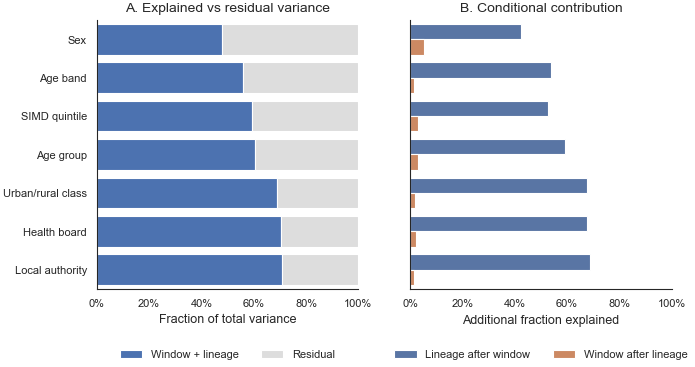

In [34]:
_, axes = new_figure(
    ncols=2,
    width="double",
    height_in=4,
    sharey=True
)

# -------------------------
# Panel A: explained/residual
# -------------------------

ax = axes[0]
y = np.arange(len(vs))

ax.barh(
    y,
    vs["additive_model_fraction"],
    label="Window + lineage",
    color="#4C72B0"
)

ax.barh(
    y,
    vs["residual_fraction_additive"],
    left=vs["additive_model_fraction"],
    label="Residual",
    color="#DDDDDD"
)

ax.set_yticks(y)
ax.set_yticklabels(vs["attribute_label"])

ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))

ax.set_xlabel("Fraction of total variance")
ax.set_title("A. Explained vs residual variance")
ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.3),
    ncol=2,
    frameon=False
)


# -------------------------
# Panel B: conditional effects
# -------------------------

ax = axes[1]

sns.barplot(
    data=conditional,
    x="fraction",
    y="attribute_label",
    hue="component",
    order=vs["attribute_label"],
    ax=ax
)

ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))

ax.set_xlabel("Additional fraction explained")
ax.set_ylabel("")
ax.set_title("B. Conditional contribution")
ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.3),
    ncol=2,
    frameon=False
)

plt.tight_layout()
plt.show()


In [35]:
def variance_decomposition_additive_wls(data):
    d = data[
        ["window_id", "pango_lineage", "assortativity", "assortativity_se"]
    ].dropna().copy()

    d = d[
        np.isfinite(d["assortativity"]) &
        np.isfinite(d["assortativity_se"]) &
        (d["assortativity_se"] > 0)
    ]

    if len(d) < 5:
        return pd.Series(dtype=float)

    d["window_id"] = d["window_id"].astype("category")
    d["pango_lineage"] = d["pango_lineage"].astype("category")

    d["w"] = 1 / d["assortativity_se"] ** 2

    m0 = smf.wls(
        "assortativity ~ 1",
        data=d,
        weights=d["w"]
    ).fit()

    m_window = smf.wls(
        "assortativity ~ C(window_id)",
        data=d,
        weights=d["w"]
    ).fit()

    m_lineage = smf.wls(
        "assortativity ~ C(pango_lineage)",
        data=d,
        weights=d["w"]
    ).fit()

    m_both = smf.wls(
        "assortativity ~ C(window_id) + C(pango_lineage)",
        data=d,
        weights=d["w"]
    ).fit()

    ss_total = m0.ssr

    if ss_total <= 0:
        return pd.Series(dtype=float)

    window_alone = m0.ssr - m_window.ssr
    lineage_alone = m0.ssr - m_lineage.ssr

    additive_explained = m0.ssr - m_both.ssr

    lineage_given_window = m_window.ssr - m_both.ssr
    window_given_lineage = m_lineage.ssr - m_both.ssr

    residual = m_both.ssr

    return pd.Series({
        "n": len(d),
        "n_windows": d["window_id"].nunique(),
        "n_lineages": d["pango_lineage"].nunique(),

        "weighted_total_ss": ss_total,

        "window_alone_fraction_wls": window_alone / ss_total,
        "lineage_alone_fraction_wls": lineage_alone / ss_total,

        "additive_model_fraction_wls": additive_explained / ss_total,
        "residual_fraction_wls": residual / ss_total,

        "lineage_given_window_fraction_wls": lineage_given_window / ss_total,
        "window_given_lineage_fraction_wls": window_given_lineage / ss_total,

        "median_boot_se": d["assortativity_se"].median(),
        "median_ci_width": d["ci_width"].median() if "ci_width" in d.columns else np.nan
    })

In [36]:
vs = (
    ass
    .groupby(["attribute", "attribute_label"], observed=True)
    .apply(variance_decomposition_additive_wls)
    .reset_index()
)

vs = vs.sort_values("additive_model_fraction_wls", ascending=True)

conditional = vs.melt(
    id_vars=["attribute", "attribute_label"],
    value_vars=[
        "lineage_given_window_fraction_wls",
        "window_given_lineage_fraction_wls",
    ],
    var_name="component",
    value_name="fraction"
)

conditional["component"] = conditional["component"].replace({
    "lineage_given_window_fraction_wls": "Lineage after window",
    "window_given_lineage_fraction_wls": "Window after lineage",
})

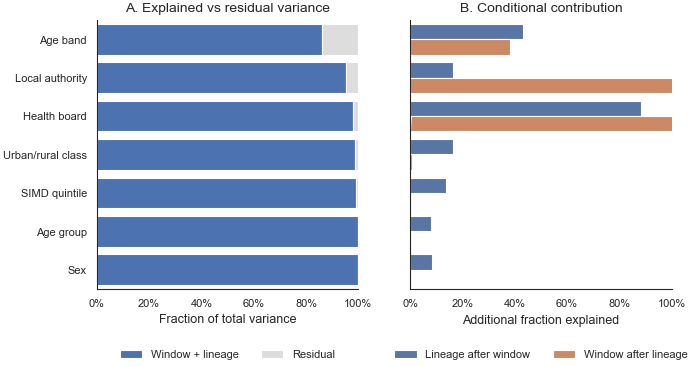

In [37]:
_, axes = new_figure(
    ncols=2,
    width="double",
    height_in=4,
    sharey=True
)

# -------------------------
# Panel A: explained/residual
# -------------------------

ax = axes[0]
y = np.arange(len(vs))

ax.barh(
    y,
    vs["additive_model_fraction_wls"],
    label="Window + lineage",
    color="#4C72B0"
)

ax.barh(
    y,
    vs["residual_fraction_wls"],
    left=vs["additive_model_fraction_wls"],
    label="Residual",
    color="#DDDDDD"
)

ax.set_yticks(y)
ax.set_yticklabels(vs["attribute_label"])

ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))

ax.set_xlabel("Fraction of total variance")
ax.set_title("A. Explained vs residual variance")
ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.3),
    ncol=2,
    frameon=False
)


# -------------------------
# Panel B: conditional effects
# -------------------------

ax = axes[1]

sns.barplot(
    data=conditional,
    x="fraction",
    y="attribute_label",
    hue="component",
    order=vs["attribute_label"],
    ax=ax
)

ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(PercentFormatter(1.0))

ax.set_xlabel("Additional fraction explained")
ax.set_ylabel("")
ax.set_title("B. Conditional contribution")
ax.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.3),
    ncol=2,
    frameon=False
)

plt.tight_layout()
plt.show()


You could report the result like this:

Weighted assortativity was computed from the undirected weighted edge list using the weighted mixing matrix for categorical attributes and weighted endpoint correlation for numeric attributes. Uncertainty was estimated using a multiplier bootstrap over edges with 500 replicates.

Or for strength:

Weighted degree assortativity was computed as the weighted Pearson correlation of endpoint node strengths, with node strengths recomputed within each bootstrap replicate.